In [30]:
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import numpy as np
import jdcal as j 
from astropy.time import Time
from pathlib import Path

import pandas as pd

from starsim import nbspectra

from scipy import optimize

from RACCON_Gaussian_fit import *

In [31]:
vsini = 2021.5337025818953

def gaussian2(x, amplitude, mean, stddev,C):
    return C + amplitude * np.exp(-(x-mean)**2/(2*stddev**2))

def compute_ccf_params_test(rv,ccf,plot_test):
    '''
    Compute the parameters of the CCF and its bisector span 
    (10-40% bottom minus 60-90% top)
    '''
    rvs=np.zeros(len(ccf)) #initialize
    fwhm=np.zeros(len(ccf))
    contrast=np.zeros(len(ccf))
    BIS=np.zeros(len(ccf))
    #bisector F/F_c
    raw_xbis = []
    raw_ybis = []


    for i in range(len(ccf)): #loop for each ccf
        ccf[i] = ccf[i] - ccf[i].min() + 0.000001
        #Compute bisector and remove wings
        cutleft0,cutright0,xbis,ybis=nbspectra.speed_bisector_nb(rv,ccf[i]/ccf[i].max(),integrated_bis=True) #FAST
        # cutleft0,cutright0,xbis,ybis=nbspectra.speed_bisector_nb(rv,ccf[i],integrated_bis=True) #test


        raw_xbis.append(xbis)
        raw_ybis.append(ybis)
        BIS[i]=np.mean(xbis[np.array(ybis>=0.1) & np.array(ybis<=0.4)])-np.mean(xbis[np.array(ybis<=0.9) & np.array(ybis>=0.6)]) #FAST
        if i==0:
            cutleft,cutright=cutleft0,cutright0
        try:
            popt,_=optimize.curve_fit(nbspectra.gaussian2, rv[cutleft:cutright], ccf[i][cutleft:cutright],p0=[np.max(ccf[i][cutleft:cutright]),rv[cutleft:cutright][np.argmax(ccf[i][cutleft:cutright])]+100,1.5*vsini+1000,0.000001]) #fit a gaussian
        except:
            print('oups')
            popt=[1.0,100000.0,1,100000.0]
        contrast[i]=popt[0] #amplitude
        rvs[i]=popt[1] #mean
        fwhm[i]=2*np.sqrt(2*np.log(2))*np.abs(popt[2]) #fwhm relation to std

        if plot_test: 
            # plt.plot(rv,1-ccf[i]/ccf[i].max())
            plt.plot(xbis,1-ybis,'b')
            plt.show(block=True)


    return rvs, contrast, fwhm, BIS, raw_xbis, raw_ybis

In [32]:
ccf_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/ccf_test_mps.txt')
rv_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/rv_test_mps.txt')

[harps_days, harps_daily_av] = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/harps/harps_rv_daily_averaged.txt')

rv0 = -1014.13101399

change=10

rv_sim = np.arange(-18.0,18.0+0.25,0.25)

rv0 = -1014.13851768

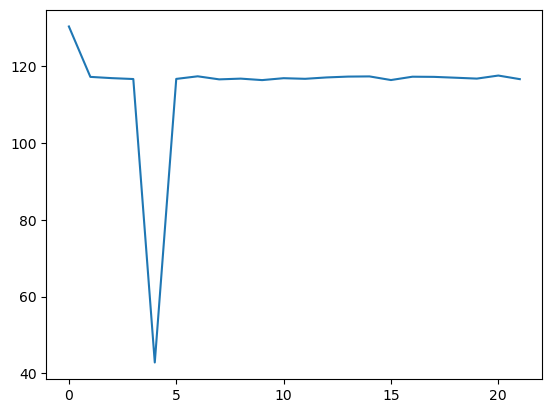

In [43]:
# rvs, contrast, fwhm, BIS, raw_xbis, raw_ybis = spectra.compute_ccf_params(None, CCF_rv * 1e3,  1-np.array(ccf[1:]), False)
rvs, contrast, fwhm, BIS, raw_xbis, raw_ybis = compute_ccf_params_test(CCF_rv*1e3,  1 - np.array(ccf[1:]), False)

plt.plot(rvs)

In [50]:
cff_list = []

base_path = Path("/home/sophie-stucki/Documents/starsim_simulations/harps/")


def open_all_fits_files(root_dir):
    ccf_list = []  # To store opened FITS HDUs or data
    
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for file in filenames:
            if file.lower().endswith('.fits'):
                full_path = os.path.join(dirpath, file)
                try:
                    ccf_header = fits.getheader(full_path)
                    ccf = fits.getdata(full_path, 1)
                    ccf_list.append(ccf[-1] / max(ccf[-1]))

                    CCF_rv =np.arange(
                        ccf_header["TNG RV START"],
                        ccf_header["TNG RV START"] + len(ccf[0]) * ccf_header["TNG RV STEP"],
                        ccf_header["TNG RV STEP"],
                    )

                except Exception as e:
                    print(f"Failed to open {full_path}: {e}")

        
    return CCF_rv, ccf_list

daily_rv = []
days = []

daily_rv_ss = []

for ccf_dir in sorted(base_path.glob("sun_spectroscopy_data_ccf_*")):
    print(f"\n📂 Processing: {ccf_dir.name}")
    days.append(str(ccf_dir).replace('/home/sophie-stucki/Documents/starsim_simulations/harps/sun_spectroscopy_data_ccf_', ''))
    CCF_rv, ccf = open_all_fits_files(ccf_dir)
    con_list,rv_list,fwhm_list,bis_list,gaussian,ccf_corr,offset =RACCOON_gaussian_corr(CCF_rv,ccf,mode='all')

    rv_ss, contrast, fwhm, BIS, raw_xbis, raw_ybis = compute_ccf_params_test(CCF_rv*1e3, 1 - np.array(ccf), False)

    daily_rv.append(np.mean(rv_list))
    daily_rv_ss.append(np.mean(rv_ss))

days = np.int32(days)

daily_rv[np.nanargmax(daily_rv)] = np.nan
idxs = np.argsort(days)
days= days[idxs]
daily_rv = np.array(daily_rv)[idxs]
daily_rv_ss = np.array(daily_rv_ss)[idxs]


📂 Processing: sun_spectroscopy_data_ccf_0

📂 Processing: sun_spectroscopy_data_ccf_1

📂 Processing: sun_spectroscopy_data_ccf_10

📂 Processing: sun_spectroscopy_data_ccf_12

📂 Processing: sun_spectroscopy_data_ccf_14

📂 Processing: sun_spectroscopy_data_ccf_15

📂 Processing: sun_spectroscopy_data_ccf_16

📂 Processing: sun_spectroscopy_data_ccf_17

📂 Processing: sun_spectroscopy_data_ccf_18

📂 Processing: sun_spectroscopy_data_ccf_19

📂 Processing: sun_spectroscopy_data_ccf_2

📂 Processing: sun_spectroscopy_data_ccf_20

📂 Processing: sun_spectroscopy_data_ccf_21

📂 Processing: sun_spectroscopy_data_ccf_22

📂 Processing: sun_spectroscopy_data_ccf_23

📂 Processing: sun_spectroscopy_data_ccf_25

📂 Processing: sun_spectroscopy_data_ccf_26

📂 Processing: sun_spectroscopy_data_ccf_27

📂 Processing: sun_spectroscopy_data_ccf_28

📂 Processing: sun_spectroscopy_data_ccf_29

📂 Processing: sun_spectroscopy_data_ccf_3

📂 Processing: sun_spectroscopy_data_ccf_30

📂 Processing: sun_spectroscopy_data

/home/sophie-stucki/anaconda3/envs/starsim/lib/python3.13/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/home/sophie-stucki/anaconda3/envs/starsim/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sophie-stucki/anaconda3/envs/starsim/lib/python3.13/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



📂 Processing: sun_spectroscopy_data_ccf_55

📂 Processing: sun_spectroscopy_data_ccf_56

📂 Processing: sun_spectroscopy_data_ccf_57

📂 Processing: sun_spectroscopy_data_ccf_58

📂 Processing: sun_spectroscopy_data_ccf_59

📂 Processing: sun_spectroscopy_data_ccf_6

📂 Processing: sun_spectroscopy_data_ccf_60

📂 Processing: sun_spectroscopy_data_ccf_61

📂 Processing: sun_spectroscopy_data_ccf_7

📂 Processing: sun_spectroscopy_data_ccf_8

📂 Processing: sun_spectroscopy_data_ccf_9


In [48]:
con_list,rv_list,fwhm_list,bis_list,gaussian,ccf_corr,offset =RACCOON_gaussian_corr(1e-3 * ccf_simu_mps[0],( 1- ccf_simu_mps[1:]),mode='all')


In [67]:
masks = daily_rv_ss == np.max(daily_rv_ss)

days[~masks]

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 12, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 39, 41, 42, 43, 44, 48, 49, 50, 51, 53, 55, 56, 57, 58, 59, 60,
       61], dtype=int32)

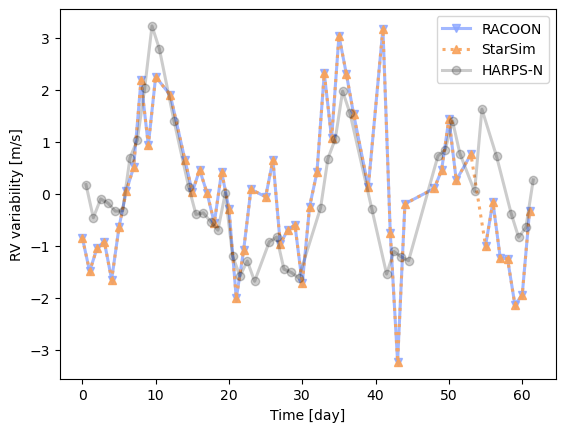

In [95]:
plt.plot(days, 1e3 * (np.array(daily_rv) - np.nanmean(daily_rv)), 'v-', label='RACOON', color='#8ba6ff', alpha=0.8, linewidth=2.2)
plt.plot(days[~masks],  (np.array(daily_rv_ss[~masks]) - np.nanmean(daily_rv_ss[~masks])), '^:', label='StarSim', color='#f8a25b', alpha=0.9, linewidth=2.2)

plt.plot(harps_days, harps_daily_av - np.nanmean(harps_daily_av), 'o-', label='HARPS-N', color="#000000", alpha=0.2, linewidth=2.2)

plt.legend()
plt.xlabel('Time [day]')
plt.ylabel('RV variability [m/s]')
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comp_rv_fit.png')
# plt.ylim(-10,20)
# plt.plot(range(62), (np.array(rv_list) - np.mean(rv_list)), 'sr-')
# df = pd.DataFrame({
#         "days": days,
#         "rv": daily_rv
#     })

# df.to_csv('/home/sophie-stucki/Documents/starsim_simulations/harps/rv.csv', index=False)

# df2 = pd.DataFrame({
#         "days": range(62),
#         "rv": 1e3*np.array(rv_list)
#     })